In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(r'D:\Supply_chain_project\data\IPG3344S.csv')

df['observation_date'] = pd.to_datetime(df['observation_date'], format='%d-%m-%Y') # Parse dates in DD-MM-YYYY format
df = df.sort_values('observation_date').reset_index(drop=True)

print("Shape:", df.shape)
print("\nDate range:", df['observation_date'].min(), "to", df['observation_date'].max())
print("\nFirst 5 rows:")
print(df.head())
print("\nLast 5 rows:")
print(df.tail())
print("\nMissing values:", df['IPG3344S'].isna().sum())
print("\nData types:")
print(df.dtypes)

Shape: (652, 2)

Date range: 1972-01-01 00:00:00 to 2026-04-01 00:00:00

First 5 rows:
  observation_date  IPG3344S
0       1972-01-01    0.0290
1       1972-02-01    0.0286
2       1972-03-01    0.0286
3       1972-04-01    0.0290
4       1972-05-01    0.0291

Last 5 rows:
    observation_date  IPG3344S
647       2025-12-01  170.4877
648       2026-01-01  176.9155
649       2026-02-01  175.9700
650       2026-03-01  176.4421
651       2026-04-01  178.2297

Missing values: 0

Data types:
observation_date    datetime64[ns]
IPG3344S                   float64
dtype: object


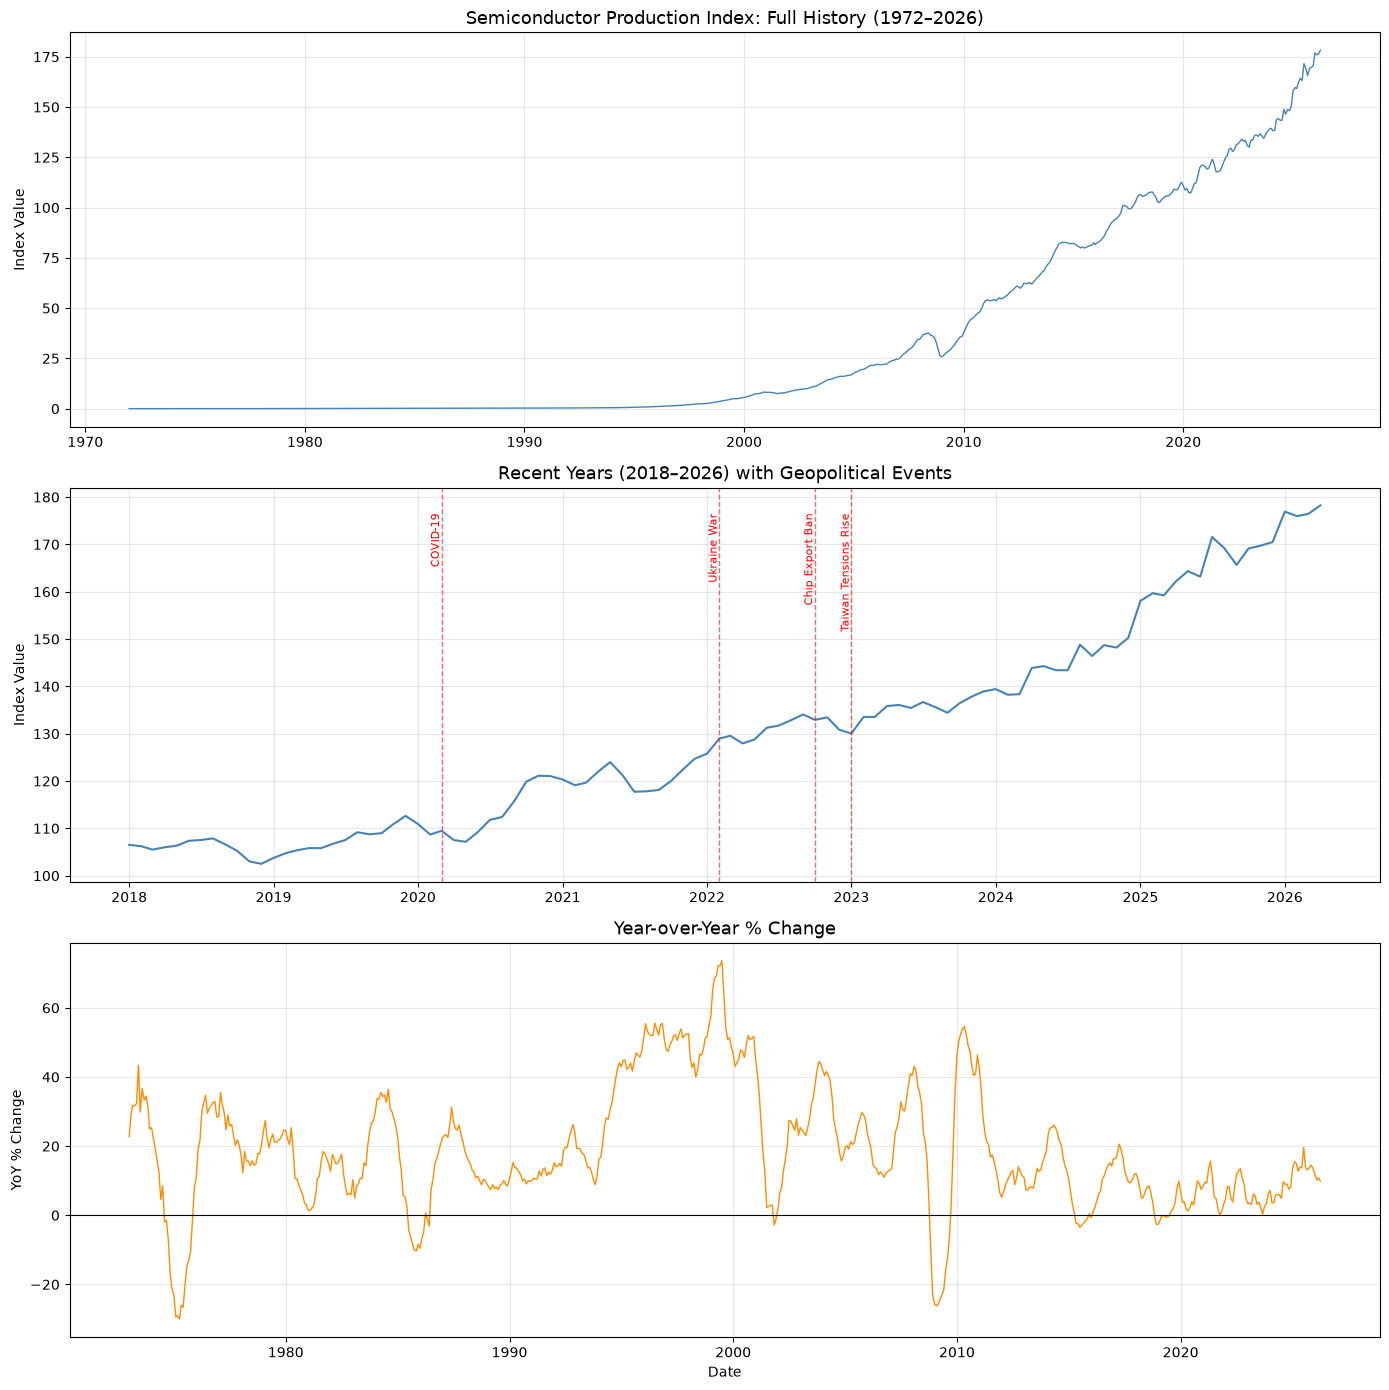

In [2]:
import matplotlib.dates as mdates

fig, axes = plt.subplots(3, 1, figsize=(14, 14))

axes[0].plot(df['observation_date'], df['IPG3344S'], color='steelblue', linewidth=1)
axes[0].set_title('Semiconductor Production Index: Full History (1972–2026)', fontsize=13)
axes[0].set_ylabel('Index Value')
axes[0].grid(alpha=0.3)

recent = df[df['observation_date'] >= '2018-01-01']
axes[1].plot(recent['observation_date'], recent['IPG3344S'], color='steelblue', linewidth=1.5)
events = {
    '2020-03-01': 'COVID-19',
    '2022-02-01': 'Ukraine War',
    '2022-10-01': 'Chip Export Ban',
    '2023-01-01': 'Taiwan Tensions Rise',
}
for date_str, label in events.items():
    event_date = pd.to_datetime(date_str)
    axes[1].axvline(event_date, color='red', linestyle='--', alpha=0.6, linewidth=1)
    axes[1].text(event_date, axes[1].get_ylim()[1]*0.97, label, rotation=90,
                 fontsize=8, color='red', va='top', ha='right')
axes[1].set_title('Recent Years (2018–2026) with Geopolitical Events', fontsize=13)
axes[1].set_ylabel('Index Value')
axes[1].grid(alpha=0.3)

df['yoy_change'] = df['IPG3344S'].pct_change(periods=12) * 100
axes[2].plot(df['observation_date'], df['yoy_change'], color='darkorange', linewidth=1)
axes[2].axhline(0, color='black', linewidth=0.8)
axes[2].set_title('Year-over-Year % Change', fontsize=13)
axes[2].set_ylabel('YoY % Change')
axes[2].set_xlabel('Date')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [3]:
features_df = df.copy()

features_df['lag_1'] = features_df['IPG3344S'].shift(1)
features_df['lag_3'] = features_df['IPG3344S'].shift(3)
features_df['lag_12'] = features_df['IPG3344S'].shift(12)

features_df['rolling_mean_3'] = features_df['IPG3344S'].shift(1).rolling(window=3).mean()
features_df['rolling_mean_6'] = features_df['IPG3344S'].shift(1).rolling(window=6).mean()
features_df['rolling_mean_12'] = features_df['IPG3344S'].shift(1).rolling(window=12).mean()
features_df['rolling_std_3'] = features_df['IPG3344S'].shift(1).rolling(window=3).std()

features_df['month'] = features_df['observation_date'].dt.month


features_df['mom_change'] = features_df['IPG3344S'].pct_change(periods=1) * 100
features_df['yoy_change'] = features_df['IPG3344S'].pct_change(periods=12) * 100

features_df_clean = features_df.dropna().reset_index(drop=True)

print("Original rows:", len(features_df))
print("Rows after dropping NaN:", len(features_df_clean))
print("\nColumns:", list(features_df_clean.columns))
print("\nFirst 5 rows of engineered features:")
print(features_df_clean[['observation_date', 'IPG3344S', 'lag_1', 'lag_3', 'lag_12', 'rolling_mean_3', 'rolling_mean_6', 'rolling_mean_12', 'rolling_std_3', 'month', 'mom_change', 'yoy_change']].head())

Original rows: 652
Rows after dropping NaN: 640

Columns: ['observation_date', 'IPG3344S', 'yoy_change', 'lag_1', 'lag_3', 'lag_12', 'rolling_mean_3', 'rolling_mean_6', 'rolling_mean_12', 'rolling_std_3', 'month', 'mom_change']

First 5 rows of engineered features:
  observation_date  IPG3344S   lag_1   lag_3  lag_12  rolling_mean_3  \
0       1973-01-01    0.0356  0.0356  0.0319  0.0290        0.033633   
1       1973-02-01    0.0370  0.0356  0.0334  0.0286        0.034867   
2       1973-03-01    0.0377  0.0370  0.0356  0.0286        0.036067   
3       1973-04-01    0.0382  0.0377  0.0356  0.0290        0.036767   
4       1973-05-01    0.0385  0.0382  0.0370  0.0291        0.037633   

   rolling_mean_6  rolling_mean_12  rolling_std_3  month  mom_change  \
0        0.031933         0.030392       0.001861      1    0.000000   
1        0.032900         0.030942       0.001270      2    3.932584   
2        0.034067         0.031642       0.000808      3    1.891892   
3        0.03

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

train = features_df_clean[features_df_clean['observation_date'] < '2023-01-01'].copy()
test = features_df_clean[features_df_clean['observation_date'] >= '2023-01-01'].copy()

print("Train rows:", len(train), "| Test rows:", len(test))
print("Train range:", train['observation_date'].min(), "to", train['observation_date'].max())
print("Test range:", test['observation_date'].min(), "to", test['observation_date'].max())

baseline_preds = test['rolling_mean_3']
baseline_actual = test['IPG3344S']

baseline_mae = mean_absolute_error(baseline_actual, baseline_preds)
baseline_rmse = np.sqrt(mean_squared_error(baseline_actual, baseline_preds))

print(f"\nBaseline (rolling avg) MAE: {baseline_mae:.4f}")
print(f"Baseline (rolling avg) RMSE: {baseline_rmse:.4f}")

Train rows: 600 | Test rows: 40
Train range: 1973-01-01 00:00:00 to 2022-12-01 00:00:00
Test range: 2023-01-01 00:00:00 to 2026-04-01 00:00:00

Baseline (rolling avg) MAE: 2.6633
Baseline (rolling avg) RMSE: 3.4398


In [ ]:
from xgboost import XGBRegressor

features_df_clean['target_diff'] = features_df_clean['IPG3344S'].diff()

data = features_df_clean.dropna(subset=['target_diff']).reset_index(drop=True)

train = data[data['observation_date'] < '2023-01-01'].copy()
test = data[data['observation_date'] >= '2023-01-01'].copy()

feature_cols = ['lag_1', 'lag_3', 'lag_12',
                'rolling_mean_3', 'rolling_mean_6', 'rolling_mean_12',
                'rolling_std_3', 'month', 'mom_change', 'yoy_change']

X_train = train[feature_cols]
y_train = train['target_diff']
X_test = test[feature_cols]
y_test_diff = test['target_diff']

model = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=4, random_state=42)
model.fit(X_train, y_train)

pred_diff = model.predict(X_test)

prev_values = test['IPG3344S'].shift(1)
prev_values.iloc[0] = train['IPG3344S'].iloc[-1]
xgb_preds_level = prev_values.values + pred_diff

y_test_level = test['IPG3344S']
xgb_mae = mean_absolute_error(y_test_level, xgb_preds_level)
xgb_rmse = np.sqrt(mean_squared_error(y_test_level, xgb_preds_level))

print(f"XGBoost (differenced) MAE:  {xgb_mae:.4f}  (baseline: {baseline_mae:.4f})")
print(f"XGBoost (differenced) RMSE: {xgb_rmse:.4f}  (baseline: {baseline_rmse:.4f})")

improvement = (baseline_mae - xgb_mae) / baseline_mae * 100
print(f"MAE improvement over baseline: {improvement:.1f}%")

XGBoost (differenced) MAE:  0.6426  (baseline: 2.6633)
XGBoost (differenced) RMSE: 1.2220  (baseline: 3.4398)
MAE improvement over baseline: 75.9%


rolling_mean_3     0.379030
mom_change         0.183415
lag_1              0.141106
rolling_mean_6     0.099957
rolling_mean_12    0.080057
lag_12             0.057157
rolling_std_3      0.042773
lag_3              0.014458
yoy_change         0.001348
month              0.000700
dtype: float32


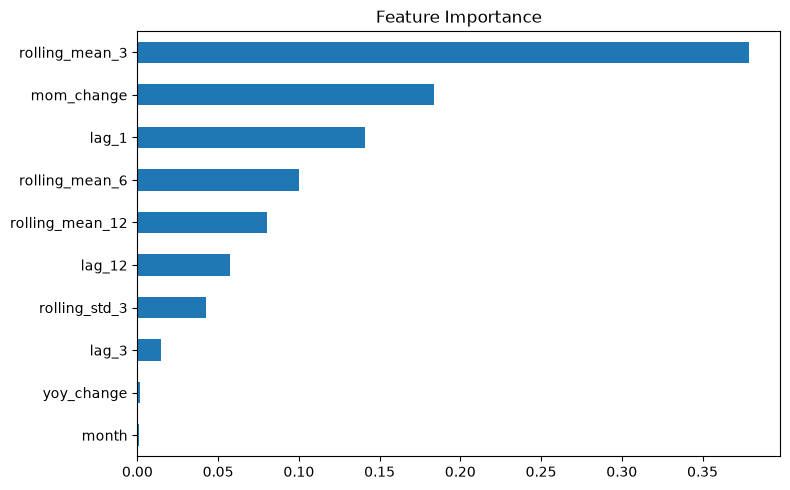

In [9]:
importances = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)
print(importances)
importances.plot(kind='barh', figsize=(8,5), title='Feature Importance').invert_yaxis()
plt.tight_layout(); plt.show()

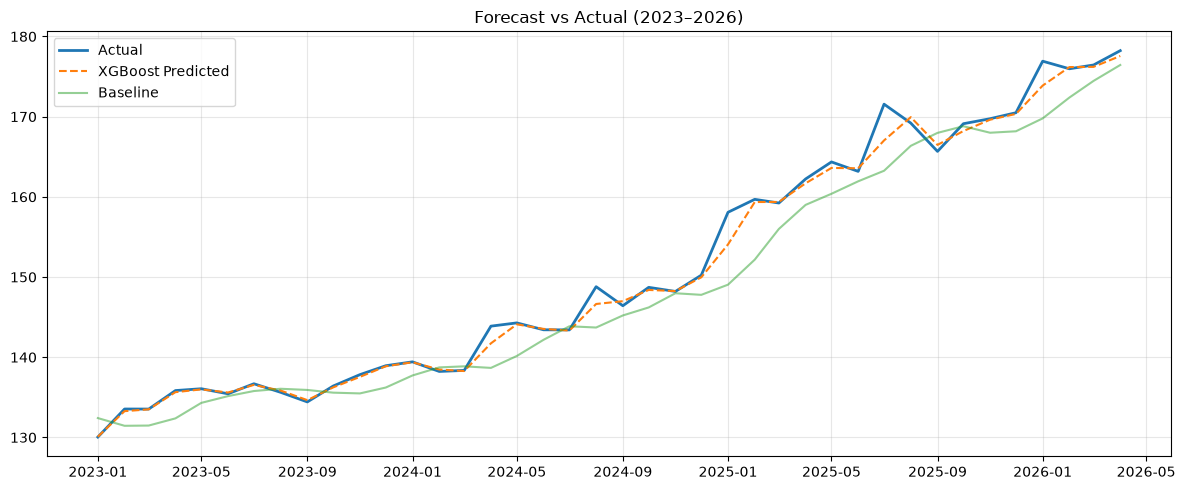

In [10]:
plt.figure(figsize=(12,5))
plt.plot(test['observation_date'], y_test_level.values, label='Actual', linewidth=2)
plt.plot(test['observation_date'], xgb_preds_level, label='XGBoost Predicted', linestyle='--')
plt.plot(test['observation_date'], test['rolling_mean_3'].values, label='Baseline', alpha=0.5)
plt.legend(); plt.title('Forecast vs Actual (2023–2026)'); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [11]:
import pickle, os
os.makedirs(r'D:\Supply_chain_project\models', exist_ok=True)
with open(r'D:\Supply_chain_project\models\xgb_model.pkl', 'wb') as f:
    pickle.dump({'model': model, 'feature_cols': feature_cols}, f)
print("Saved.")

Saved.


In [13]:
data['covid'] = ((data['observation_date'] >= '2020-03-01') & (data['observation_date'] <= '2020-12-01')).astype(int)
data['export_ban'] = (data['observation_date'] >= '2022-10-01').astype(int)
data['taiwan_tension'] = (data['observation_date'] >= '2023-01-01').astype(int)

feature_cols_geo = feature_cols + ['covid', 'export_ban', 'taiwan_tension']

train = data[data['observation_date'] < '2023-01-01'].copy()
test = data[data['observation_date'] >= '2023-01-01'].copy()

m2 = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=4, random_state=42)
m2.fit(train[feature_cols_geo], train['target_diff'])

pred_diff_geo = m2.predict(test[feature_cols_geo])
pv = test['IPG3344S'].shift(1)
pv.iloc[0] = train['IPG3344S'].iloc[-1]
preds_geo = pv.values + pred_diff_geo

mae2 = mean_absolute_error(test['IPG3344S'], preds_geo)
print(f"With geo features MAE: {mae2:.4f}  (without: {xgb_mae:.4f})")

With geo features MAE: 0.6374  (without: 0.6426)
